# Photo-z estimation with UMAP

In [1]:
### Imports
from rail.core.data import DataStore
from rail.core.stage import RailStage
from rail.core.data import PqHandle

import numpy as np
import h5py
import tables_io

from UMAPEstimator import UMAPEstimator

# Specify paths and parameters

In [2]:
### Specify path to noisy catalog
noisy_catalog_path = '/Users/leo/Projects/LBG_cosmology/simulated_catalogs/integrated_catalog_23apr26_noised_19Jun26.pq'

### Specify path to output photometry
import time
date = time.strftime('%d%b%y', time.localtime())
photoz_path = noisy_catalog_path.split('.pq')[0] + f'_UMAPphotoz_{date}.pq'

In [3]:
### Specify model parameters
training_fraction = 0.8


metric            = "manhattan_weighted_linear"
seed              = 42

# Split data into training and validation

In [4]:
data = tables_io.read(noisy_catalog_path)

data_cut = int(1e3)
data = data[:data_cut]

training_indices = np.zeros(len(data), dtype = bool)
training_indices[np.random.choice(len(data), size = int(training_fraction * len(data)),
                 replace = False)] = True

bands = [key for key in data.keys() if (not key.endswith('_err')) & (key != 'Roman_F146')]
error_bands = [key for key in data.keys() if key.endswith('_err')]

validation_data = data[~training_indices]
training_data   = data[training_indices]

column_list None


In [5]:
photometry_bands = [key for key in training_data.keys()\
                        if (not key.endswith('_err')) and (key != 'Roman_F146')]
phot_error_bands = [f"{key}_err" for key in photometry_bands]

In [6]:
redshift_filepath = '/Users/leo/Projects/LBG_cosmology/surveys/pop-cosmos/mock_catalog/mock_catalog_Ch1_26.h5'
redshift          = h5py.File(redshift_filepath)['sfh_parameters'][:, -1]

training_redshift   = redshift[:data_cut][training_indices]
validation_redshift = redshift[:data_cut][~training_indices]

# Instantiate and run RAIL stage

In [7]:
RailStage.data_store = DataStore()

stage = UMAPEstimator.make_stage(
    name = "UMAP_informer",
    
    ambient_metric_umap = metric,
    
    seed = seed
)

stage.set_data("training_photometry", data = training_data[photometry_bands])
stage.set_data("training_phot_error", data = training_data[phot_error_bands])
stage.set_data("training_redshift",   data = training_redshift)

Inserting handle into data store.  training_photometry: None, UMAP_informer
Inserting handle into data store.  training_phot_error: None, UMAP_informer
Inserting handle into data store.  training_redshift: None, UMAP_informer


array([0.1092879 , 0.09602419, 0.17016256, 0.07222292, 0.12323937,
       0.13383639, 0.15923409, 0.1603817 , 0.17651452, 0.08270884,
       0.15508026, 0.21383935, 0.1655905 , 0.10060135, 0.13063174,
       0.07175412, 0.129256  , 0.16094378, 0.2408389 , 0.17588614,
       0.23156619, 0.13729158, 0.13942134, 0.19034447, 0.09347411,
       0.07178996, 0.15648504, 0.15684502, 0.14547403, 0.12437538,
       0.16284315, 0.12642746, 0.11204741, 0.11174067, 0.17662033,
       0.1303938 , 0.01875363, 0.1531041 , 0.18075211, 0.13053851,
       0.11936077, 0.07814855, 0.08076877, 0.07449096, 0.11124317,
       0.57231444, 0.13655037, 0.11322581, 0.12435413, 0.15081182,
       0.14417288, 0.23995706, 0.15239383, 0.13749155, 0.19013022,
       0.14701848, 0.15634614, 0.11501562, 0.12695222, 0.10680281,
       0.11829594, 0.1258662 , 0.01528157, 0.1714554 , 0.11044826,
       0.04257841, 0.1827475 , 0.23427503, 0.16086806, 0.12248144,
       0.08702984, 0.12034947, 0.15871151, 0.11522739, 0.13880

# Inform the estimator

In [8]:
stage.UMAP_informer()

/Users/leo/miniforge3/envs/RAIL/lib/python3.14/site-packages/umap/umap_.py:1857: UserWarning: custom distance metric does not return gradient; inverse_transform will be unavailable. To enable using inverse_transform method, define a distance function that returns a tuple of (distance [float], gradient [np.array])
  warn(
/Users/leo/miniforge3/envs/RAIL/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Inserting handle into data store.  informed_reducer_UMAP_informer: inprogress_informed_reducer_UMAP_informer.pkl, UMAP_informer
Inserting handle into data store.  informed_embedding_UMAP_informer: inprogress_informed_embedding_UMAP_informer.pq, UMAP_informer
Inserting handle into data store.  informed_kNN_regressor_UMAP_informer: inprogress_informed_kNN_regressor_UMAP_informer.pkl, UMAP_informer


# Estimate redshifts

In [9]:
stage.set_data("estimation_photometry", data = validation_data[photometry_bands])
stage.set_data("estimation_phot_error", data = validation_data[phot_error_bands])
stage.UMAP_estimator()

Inserting handle into data store.  estimation_photometry: None, UMAP_informer
Inserting handle into data store.  estimation_phot_error: None, UMAP_informer
Inserting handle into data store.  estimated_embedding_UMAP_informer: inprogress_estimated_embedding_UMAP_informer.pq, UMAP_informer
Inserting handle into data store.  estimated_photozs_UMAP_informer: inprogress_estimated_photozs_UMAP_informer.pq, UMAP_informer


In [10]:
estimated_photoz = stage.get_handle('estimated_photozs').data

# Evaluate

# Plot redshifts

In [12]:
import matplotlib.pyplot as plt
plt.style.use('/Users/leo/Projects/LBG_cosmology/code/umap_nz_cal.mplstyle')

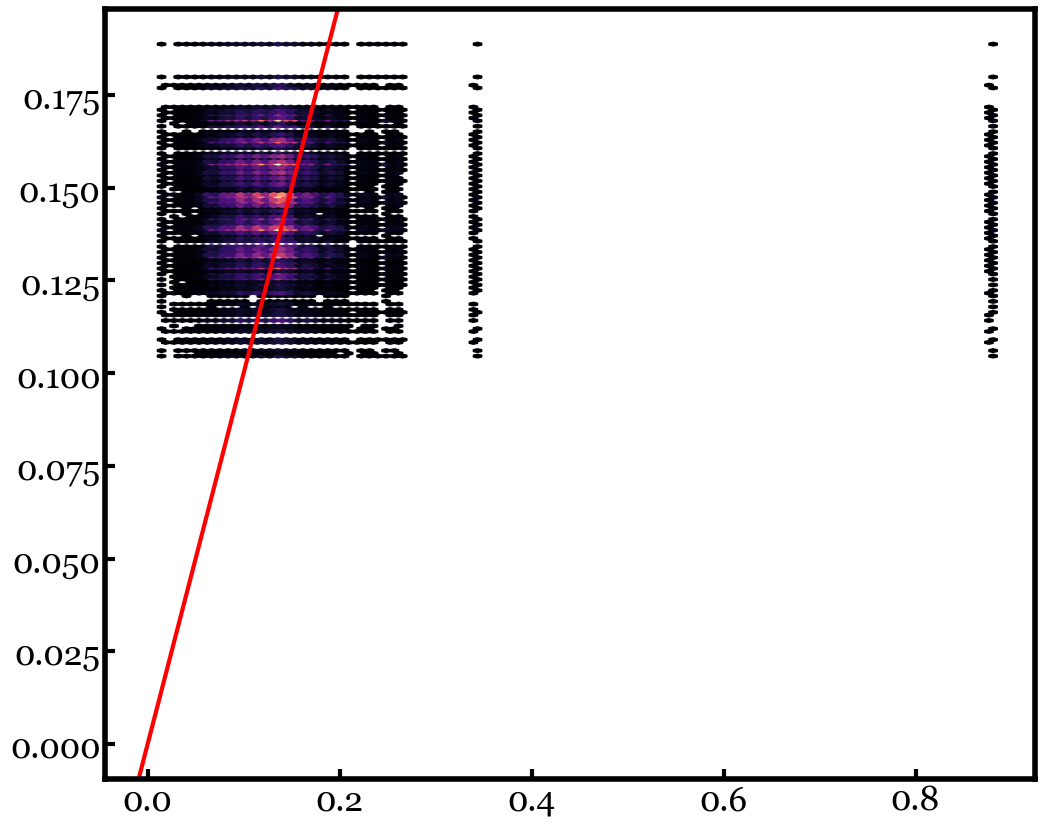

In [13]:
fig = plt.figure()
ax = fig.add_subplot()

ax.hexbin(validation_redshift, estimated_photoz,
          mincnt = 1)
ax.axline((0, 0), slope = 1, color = 'red')

In [ ]:
# Save otputs